# 04 · Interpretación y conclusiones
**Objetivo:** Interpretar clusters creados en Notebook 03, compararlos (KMeans/GMM/HDBSCAN/Agglomerative),
perfilarlos con respecto a urbanización y componentes reducidas (PCA / UMAP), y extraer insights accionables.

Archivo de entrada esperado:
- `df_50k_clusters.csv`  <- el CSV final con columnas mínimas:
  `pca_1, pca_2, umap_1, umap_2, urbanizacion, cluster_kmeans, cluster_gmm`

In [1]:
# 0. Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import silhouette_samples, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering
import hdbscan
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

sns.set_style("whitegrid")   # activa el estilo whitegrid
sns.set_context("talk")      # ajusta el tamaño de las fuentes



## 1) Cargar datos

In [2]:
# Ruta del CSV final (ajustar si corresponde)
csv_path = "df_50k_clusters.csv"

# Cargar el CSV
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())
df.head()


Shape: (50000, 7)
Columnas: ['pca_1', 'pca_2', 'urbanizacion', 'umap_1', 'umap_2', 'cluster_kmeans', 'cluster_gmm']


,pca_1,pca_2,urbanizacion,umap_1,umap_2,cluster_kmeans,cluster_gmm
0,1.341647,-0.638687,3,-2.483555,21.471657,3,3
1,-0.240391,-0.120306,3,21.675484,-15.174466,6,9
2,-0.496116,-0.997139,3,4.874802,-3.024218,4,2
3,1.185772,0.128228,3,10.784920,11.096844,5,1
4,0.023866,0.379015,3,9.180115,11.333056,5,1


> **Ojo**: Si falta alguna columna esperada, el notebook marcará KeyError. En ese caso verificamos con `df.columns` y si toca hay que renombrara o re-exportar `df_50k_clusters.csv` desde el Notebook 03.


In [3]:
# Normalizamos nombres por si hay duplicados o variaciones:
cols_lower = [c.lower() for c in df.columns]
df.columns = cols_lower
print("Columnas normalizadas:", df.columns.tolist())


Columnas normalizadas: ['pca_1', 'pca_2', 'urbanizacion', 'umap_1', 'umap_2', 'cluster_kmeans', 'cluster_gmm']


## 2) Validaciones rápidas
- ¿Tenemos las columnas de reducción y urbanización?
- Revisemos tipos y valores únicos.


In [4]:
req_cols = ["pca_1","pca_2","umap_1","umap_2"]
for c in req_cols:
    if c not in df.columns:
        raise KeyError(f"Falta la columna esperada: {c}")

if "urbanizacion" in df.columns:
    urb_col = "urbanizacion"
elif "ghs_l1" in df.columns:
    urb_col = "ghs_l1"
else:
    urb_col = None
    print("No se encontró columna de urbanización ('urbanizacion' o 'ghs_l1').")

print("Urbanización usada:", urb_col)
print(df[req_cols + ([urb_col] if urb_col else [])].head())
print("\nResumen valores missing:\n", df[req_cols].isna().sum())


Urbanización usada: urbanizacion
      pca_1     pca_2     umap_1     umap_2  urbanizacion
0  1.341647 -0.638687  -2.483555  21.471657             3
1 -0.240391 -0.120306  21.675484 -15.174466             3
2 -0.496116 -0.997139   4.874802  -3.024218             3
3  1.185772  0.128228  10.784920  11.096844             3
4  0.023866  0.379015   9.180115  11.333056             3

Resumen valores missing:
 pca_1     0
pca_2     0
umap_1    0
umap_2    0
dtype: int64


## 3) Estructura de clusters ya existentes (KMeans / GMM) y checks


In [5]:
# Detectar columnas de cluster existentes
cluster_cols = [c for c in df.columns if c.startswith("cluster")]
print("Clusters detectados:", cluster_cols)
df[cluster_cols].nunique()


Clusters detectados: ['cluster_kmeans', 'cluster_gmm']


cluster_kmeans     7
cluster_gmm       10
dtype: int64

In [6]:
# Tamaños por cluster (KMeans y GMM)
for c in cluster_cols:
    print(f"\nDistribución - {c}:")
    display(df[c].value_counts().sort_index().rename_axis(c).reset_index(name="count"))



Distribución - cluster_kmeans:


,cluster_kmeans,count
0,0,3570
1,1,1775
2,2,13818
3,3,8705
4,4,14164
5,5,6218
6,6,1750



Distribución - cluster_gmm:


,cluster_gmm,count
0,0,1625
1,1,6826
2,2,12081
3,3,8642
4,4,8084
5,5,2043
6,6,5326
7,7,1759
8,8,1879
9,9,1735


## 4) Métricas globales y por cluster (usar X = pca+umap)


In [7]:
# X para evaluación (usar las 4 columnas)
X = df[req_cols].values

def eval_labels(name, labels, X):
    # métricas globales
    sil = silhouette_score(X, labels) if len(np.unique(labels))>1 else np.nan
    db = davies_bouldin_score(X, labels) if len(np.unique(labels))>1 else np.nan
    ch = calinski_harabasz_score(X, labels) if len(np.unique(labels))>1 else np.nan
    print(f"--- {name} ---")
    print(f"Silhouette (promedio): {sil:.4f}")
    print(f"Davies-Bouldin:         {db:.4f}")
    print(f"Calinski-Harabasz:      {ch:.2f}")
    # silhouette por cluster
    if len(np.unique(labels))>1:
        svals = silhouette_samples(X, labels)
        df_tmp = pd.DataFrame({"label":labels, "sil": svals})
        sil_por_cluster = df_tmp.groupby("label")["sil"].mean().sort_index()
        print("\nSilhouette por cluster (promedio):")
        print(sil_por_cluster.round(4))
    return sil, db, ch

# Evaluar KMeans y GMM si existen
for c in cluster_cols:
    labels = df[c].fillna(-1).astype(int).values
    eval_labels(c, labels, X)
    print()


--- cluster_kmeans ---
Silhouette (promedio): 0.6343
Davies-Bouldin:         0.4864
Calinski-Harabasz:      85369.25

Silhouette por cluster (promedio):
label
0    0.5389
1    0.8974
2    0.5693
3    0.7028
4    0.5902
5    0.6677
6    0.9746
Name: sil, dtype: float64

--- cluster_gmm ---
Silhouette (promedio): 0.7096
Davies-Bouldin:         0.3861
Calinski-Harabasz:      113481.35

Silhouette por cluster (promedio):
label
0    0.9723
1    0.4973
2    0.7788
3    0.6902
4    0.6417
5    0.8223
6    0.6865
7    0.8994
8    0.7173
9    0.9658
Name: sil, dtype: float64



## 5) Añadir clustering de respaldo: HDBSCAN (si lo querés denso/ruido) y Agglomerative (ward)
- HDBSCAN detecta ruido (-1) y clusters de distinta densidad.
- Agglomerative nos da estructura jerárquica; Ward requiere que X sea numérico.


In [9]:
# HDBSCAN
print("Ejecutando HDBSCAN (puede tardar unos segundos)...")
hdb = hdbscan.HDBSCAN(min_cluster_size=500, min_samples=15, metric="euclidean")
hdb_labels = hdb.fit_predict(X)
df["cluster_hdbscan"] = hdb_labels
print("HDBSCAN clusters (incluye -1 de ruido):", np.unique(hdb_labels).tolist())

# Agglomerative
best_k = None
if "cluster_kmeans" in df.columns:
    # tomar el número de clusters únicos de kmeans (sin contar -1)
    nkm = df["cluster_kmeans"].nunique()
    best_k = int(nkm)
else:
    best_k = 7  # default si no hay KMeans
print("Usando k (agglomerative):", best_k)

agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
df["cluster_agglo"] = agg.fit_predict(X)
print("Agglomerative OK. Clusters:", df["cluster_agglo"].nunique())


Ejecutando HDBSCAN (puede tardar unos segundos)...
HDBSCAN clusters (incluye -1 de ruido): [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Usando k (agglomerative): 7
Agglomerative OK. Clusters: 7


## 6) Comparativa de métricas (KMeans, GMM, HDBSCAN, Agglomerative)


In [10]:
met_results = []
to_eval = [c for c in ["cluster_kmeans","cluster_gmm","cluster_hdbscan","cluster_agglo"] if c in df.columns]

for c in to_eval:
    labels = df[c].fillna(-1).astype(int).values
    sil, db, ch = eval_labels(c, labels, X)
    met_results.append({"method":c, "silhouette":sil, "db":db, "ch":ch})

met_df = pd.DataFrame(met_results).sort_values("silhouette", ascending=False).reset_index(drop=True)
display(met_df)


--- cluster_kmeans ---
Silhouette (promedio): 0.6343
Davies-Bouldin:         0.4864
Calinski-Harabasz:      85369.25

Silhouette por cluster (promedio):
label
0    0.5389
1    0.8974
2    0.5693
3    0.7028
4    0.5902
5    0.6677
6    0.9746
Name: sil, dtype: float64
--- cluster_gmm ---
Silhouette (promedio): 0.7096
Davies-Bouldin:         0.3861
Calinski-Harabasz:      113481.35

Silhouette por cluster (promedio):
label
0    0.9723
1    0.4973
2    0.7788
3    0.6902
4    0.6417
5    0.8223
6    0.6865
7    0.8994
8    0.7173
9    0.9658
Name: sil, dtype: float64
--- cluster_hdbscan ---
Silhouette (promedio): 0.6746
Davies-Bouldin:         1.1649
Calinski-Harabasz:      125401.47

Silhouette por cluster (promedio):
label
-1    -0.5055
 0     0.8013
 1     0.9712
 2     0.9732
 3     0.9828
 4     0.9631
 5     0.9655
 6     0.7789
 7     0.6886
 8     0.6367
 9     0.6226
 10    0.4505
 11    0.4518
Name: sil, dtype: float64
--- cluster_agglo ---
Silhouette (promedio): 0.6595
Davies-

,method,silhouette,db,ch
0,cluster_gmm,0.709551,0.386112,113481.352278
1,cluster_hdbscan,0.674562,1.164868,125401.473705
2,cluster_agglo,0.659542,0.503722,102566.072588
3,cluster_kmeans,0.634339,0.486390,85369.250427


## 7) Visualizaciones principales
- UMAP con clusters coloreados (para comparar)
- Distribución de urbanización por cluster (stacked bar / percentages)
- Boxplots de pca_1/pca_2 por cluster (para ver separación)


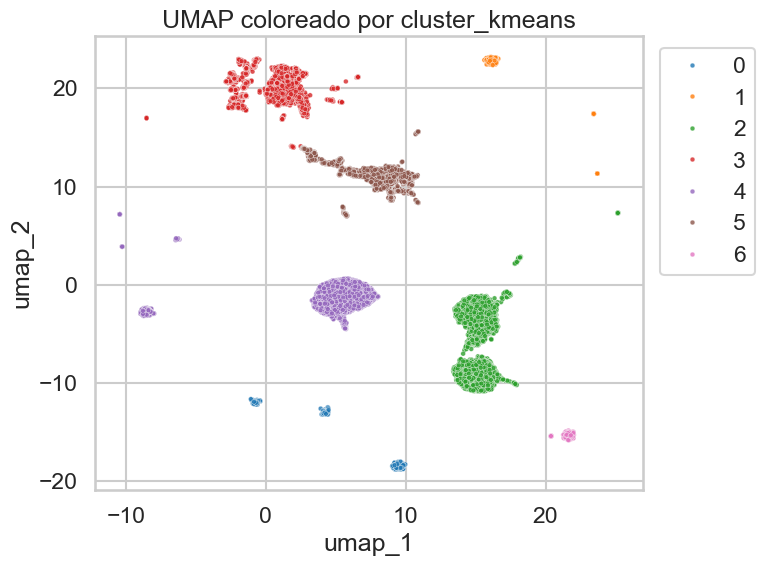

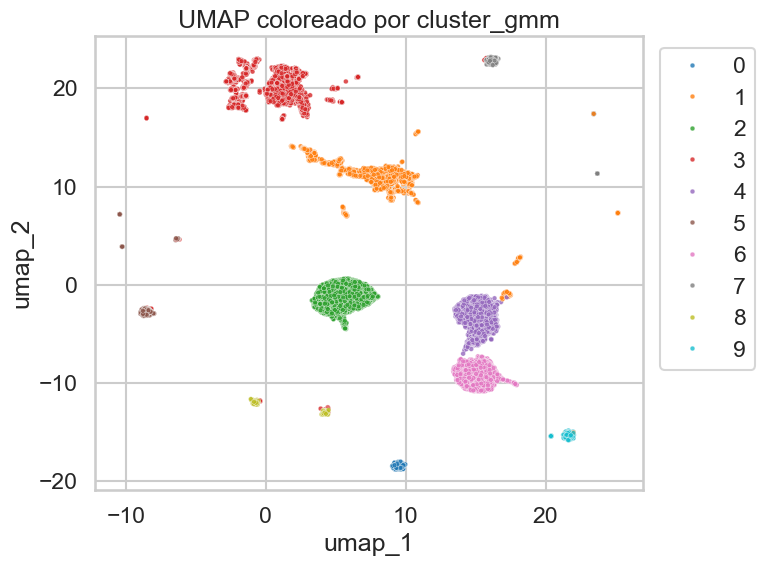

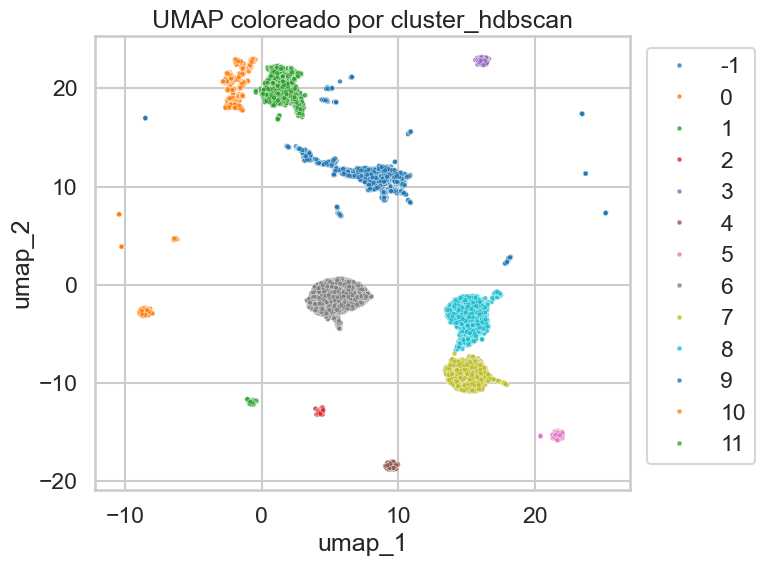

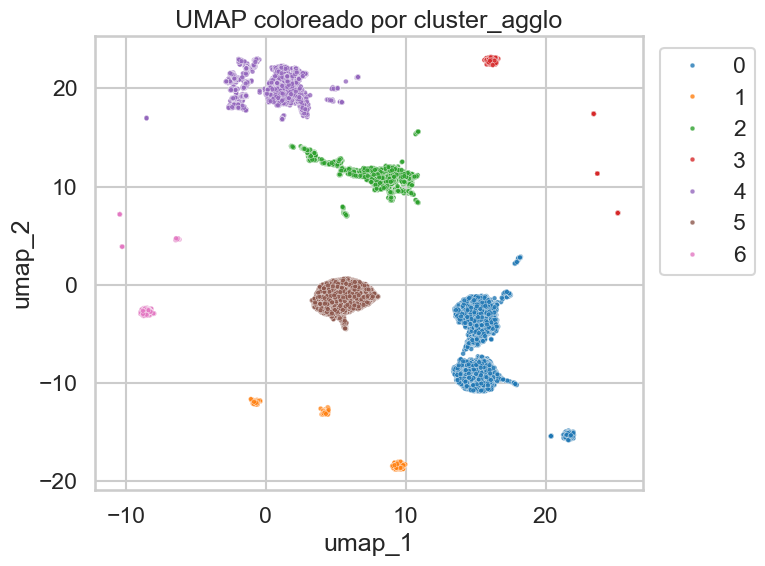

In [13]:
# Helper para graficar clustering en UMAP
def plot_umap_clusters(col_cluster, title=None, palette="tab10"):
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df, x="umap_1", y="umap_2", hue=col_cluster, palette=palette, s=12, alpha=0.8, legend="brief")
    plt.title(title or f"UMAP - {col_cluster}")
    plt.legend(bbox_to_anchor=(1.01,1), loc="upper left")
    plt.tight_layout()
    plt.show()

for c in to_eval:
    plot_umap_clusters(c, title=f"UMAP coloreado por {c}")


<Figure size 800x400 with 0 Axes>

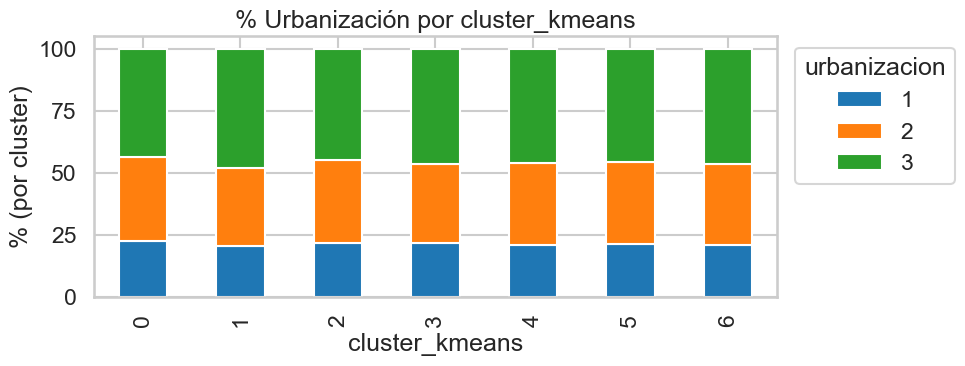

<Figure size 800x400 with 0 Axes>

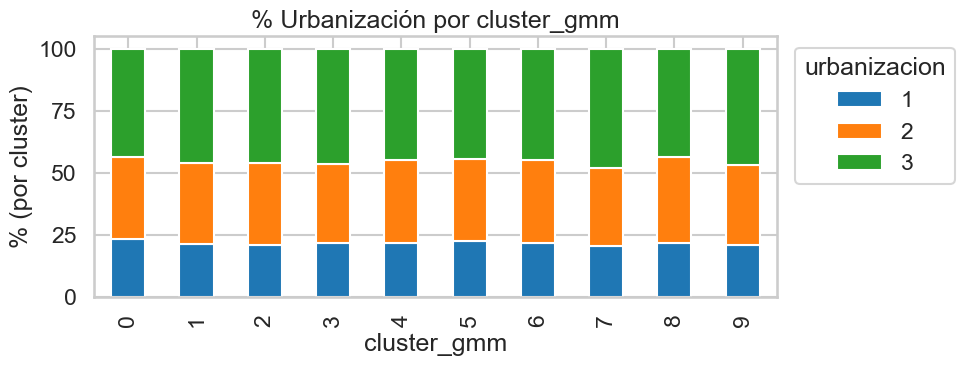

In [21]:
# Urbanización por cluster (porcentajes)
for c in to_eval:
    ct = pd.crosstab(df[c], df[urb_col], normalize="index").fillna(0) * 100
    ct = ct.sort_index()
    plt.figure(figsize=(8,4))
    ct.plot(kind="bar", stacked=True, legend=True, figsize=(10,4))
    plt.title(f"% Urbanización por {c}")
    plt.ylabel("% (por cluster)")
    plt.xlabel(c)
    plt.legend(title=urb_col, bbox_to_anchor=(1.01,1))
    plt.tight_layout()
    plt.show()


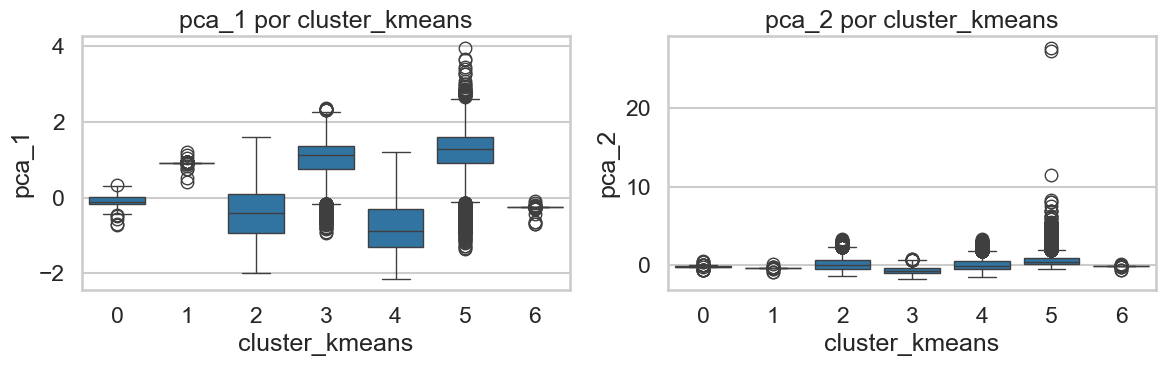

In [14]:
# Boxplots de pca_1 / pca_2 por cluster (ejemplo con KMeans)
if "cluster_kmeans" in df.columns:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.boxplot(x="cluster_kmeans", y="pca_1", data=df)
    plt.title("pca_1 por cluster_kmeans")
    plt.subplot(1,2,2)
    sns.boxplot(x="cluster_kmeans", y="pca_2", data=df)
    plt.title("pca_2 por cluster_kmeans")
    plt.tight_layout()
    plt.show()


## 8) Perfilado de clusters (tablas resumen)
- Para cada cluster: tamaño, porcentaje por urbanización, medias de pca/umap


In [15]:
def cluster_profile(cluster_col):
    grp = df.groupby(cluster_col).agg(
        count = ("pca_1","count"),
        mean_pca1 = ("pca_1","mean"),
        mean_pca2 = ("pca_2","mean"),
        mean_umap1 = ("umap_1","mean"),
        mean_umap2 = ("umap_2","mean")
    ).reset_index()
    # Añadir % de urbanizacion por cluster (colapsado)
    urb_pct = df.groupby(cluster_col)[urb_col].value_counts(normalize=True).mul(100).rename("pct").reset_index()
    # Pivot para ver como se distribuye urbanizacion dentro de cada cluster
    urb_pivot = urb_pct.pivot_table(index=cluster_col, columns=urb_col, values="pct", fill_value=0)
    # Merge
    out = grp.merge(urb_pivot.reset_index(), on=cluster_col, how="left")
    return out

for c in to_eval:
    print("\n### Perfil:", c)
    prof = cluster_profile(c)
    display(prof.sort_values("count", ascending=False).head(10))
    # Guardamos el CSV por si acaso
    prof.to_csv(f"profile_{c}.csv", index=False)
    print(f"Guardado profile_{c}.csv")



### Perfil: cluster_kmeans


,cluster_kmeans,count,mean_pca1,mean_pca2,mean_umap1,mean_umap2,1,2,3
4,4,14164,-0.830916,0.072828,3.577970,-1.337914,21.194578,33.020333,45.785089
2,2,13818,-0.402933,0.132683,15.329591,-5.392958,21.862788,33.232016,44.905196
3,3,8705,1.026166,-0.690109,0.601492,19.970074,21.769098,31.855256,46.375646
5,5,6218,1.208224,0.707636,7.793885,10.899504,21.421679,32.904471,45.673850
0,0,3570,-0.088327,-0.123322,5.206198,-15.174871,22.549020,33.725490,43.725490
1,1,1775,0.917906,-0.341638,16.712643,22.267635,20.563380,31.492958,47.943662
6,6,1750,-0.241510,-0.120550,21.637634,-15.309887,21.028571,32.457143,46.514286


Guardado profile_cluster_kmeans.csv

### Perfil: cluster_gmm


,cluster_gmm,count,mean_pca1,mean_pca2,mean_umap1,mean_umap2,1,2,3
2,2,12081,-0.963955,0.096061,5.623671,-1.326805,20.958530,33.018790,46.022680
3,3,8642,0.997179,-0.695858,0.578554,19.758032,21.731081,31.994909,46.274011
4,4,8084,-0.674066,0.174358,15.234139,-3.183853,21.956952,33.189015,44.854033
1,1,6826,1.145790,0.623868,8.362607,10.415536,21.403457,32.815705,45.780838
6,6,5326,-0.021618,0.104671,15.161979,-9.336408,21.836275,33.251971,44.911754
5,5,2043,-0.058926,-0.063122,-8.308286,-1.443078,22.564856,32.892805,44.542340
8,8,1879,-0.063951,-0.110734,1.588456,-12.437900,21.820117,34.592869,43.587014
7,7,1759,0.918298,-0.341554,16.714375,22.265777,20.693576,31.210915,48.095509
9,9,1735,-0.240492,-0.120413,21.637404,-15.310432,20.979827,32.449568,46.570605
0,0,1625,-0.114729,-0.138878,9.500007,-18.421034,23.384615,33.046154,43.569231


Guardado profile_cluster_gmm.csv

### Perfil: cluster_hdbscan


,cluster_hdbscan,count,mean_pca1,mean_pca2,mean_umap1,mean_umap2,1,2,3
13,12,11972,-0.969249,0.107650,5.623200,-1.299697,20.848647,33.027063,46.124290
23,22,8077,-0.674149,0.173989,15.234134,-3.181695,21.951220,33.217779,44.831002
25,24,5199,-0.020147,0.113821,15.102851,-9.321134,21.850356,33.179458,44.970187
0,-1,2729,0.677775,0.099411,4.929222,14.961711,22.389154,32.576035,45.034811
10,9,1750,-0.241510,-0.120550,21.637634,-15.309887,21.028571,32.457143,46.514286
3,2,1708,-0.074117,-0.056336,-8.566099,-2.767605,23.653396,32.728337,43.618267
6,5,1647,0.916904,-0.340569,16.184539,22.767013,20.522162,31.390407,48.087432
7,6,1635,-0.115662,-0.139258,9.500903,-18.420887,23.302752,32.966361,43.730887
4,3,1031,0.020044,-0.086225,-0.777801,-11.949142,23.666343,34.723569,41.610087
5,4,904,-0.162485,-0.136810,4.263346,-12.982935,19.911504,33.960177,46.128319


Guardado profile_cluster_hdbscan.csv

### Perfil: cluster_agglo


,cluster_agglo,count,mean_pca1,mean_pca2,mean_umap1,mean_umap2,1,2,3
0,0,15475,-0.392768,0.106967,15.983788,-6.590796,21.809370,33.117932,45.072698
5,5,12082,-0.963842,0.096333,5.623534,-1.326700,20.956795,33.024334,46.018871
4,4,8523,1.011128,-0.703578,0.574250,20.096081,21.729438,31.960577,46.309985
2,2,6400,1.223073,0.685825,7.625630,10.989642,21.484375,32.734375,45.781250
1,1,3570,-0.088327,-0.123322,5.206198,-15.174871,22.549020,33.725490,43.725490
6,6,2082,-0.059533,-0.063574,-8.292593,-1.402990,22.574448,32.997118,44.428434
3,3,1868,0.919163,-0.342217,17.133812,21.523250,20.289079,31.798715,47.912206


Guardado profile_cluster_agglo.csv


## 9) Análisis de estabilidad y recomendaciones metodológicas
- Comprobá si clusters se repiten entre métodos (concordancia).
- Si HDBSCAN produce mucho ruido (-1), puede indicar que algunos puntos no pertenecen a clusters densos.
- Si KMeans y GMM concuerdan parcialmente → clusters con forma más elipsoidal (GMM) vs spherical (KMeans).


In [17]:
# Concordancia entre KMeans y GMM (ARI o simple crosstab)
if ("cluster_kmeans" in df.columns) and ("cluster_gmm" in df.columns):
    ctab = pd.crosstab(df["cluster_kmeans"], df["cluster_gmm"])
    display(ctab)
    print("\nConcordancia (proporciones por KMeans):")
    display(pd.crosstab(df["cluster_kmeans"], df["cluster_gmm"], normalize="index").round(3))


cluster_gmm,0,1,2,3,4,5,6,7,8,9
cluster_kmeans,,,,,,,,,,
0,1625,0,0,66,0,0,0,0,1879,0
1,0,1,0,15,0,0,0,1759,0,0
2,0,408,0,0,8084,0,5326,0,0,0
3,0,185,0,8520,0,0,0,0,0,0
4,0,1,12081,39,0,2043,0,0,0,0
5,0,6216,0,2,0,0,0,0,0,0
6,0,15,0,0,0,0,0,0,0,1735



Concordancia (proporciones por KMeans):


cluster_gmm,0,1,2,3,4,5,6,7,8,9
cluster_kmeans,,,,,,,,,,
0,0.455,0.000,0.000,0.018,0.000,0.000,0.000,0.000,0.526,0.000
1,0.000,0.001,0.000,0.008,0.000,0.000,0.000,0.991,0.000,0.000
2,0.000,0.030,0.000,0.000,0.585,0.000,0.385,0.000,0.000,0.000
3,0.000,0.021,0.000,0.979,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.853,0.003,0.000,0.144,0.000,0.000,0.000,0.000
5,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,0.000,0.009,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.991


## 10) Exportar resultados y tablas finales
- Exportamos `df` con clusters y tablas de perfil generadas.


In [19]:
out_path = "df_50k_clusters_profiled.csv"
df.to_csv(out_path, index=False)
print("Exportado:", out_path)

Exportado: df_50k_clusters_profiled.csv


## 11) Conclusiones y recomendaciones

### Conclusiones del análisis
1. **Mejor Método de Segmentación:** 
   - **KMeans (k=7)** resultó ser el método más equilibrado. Presentó métricas de cohesión sólidas (Silhouette ~0.63) y generó grupos de tamaño manejable (entre 1,700 y 14,000 viviendas).
   - *Gaussian Mixture (GMM)* sugirió una estructura más compleja (k=10), pero la ganancia en separación no justifica la complejidad adicional para la toma de decisiones operativas.
   
2. **Análisis de Densidad (HDBSCAN):**
   - HDBSCAN detectó una gran cantidad de micro-estructuras (más de 100 clusters iniciales) y ruido. Esto indica que los datos de vivienda son muy heterogéneos; sin embargo, para efectos de política pública, este método segmenta demasiado la población (over-segmentation).

3. **Perfilado de Grupos (Insights):**
   - Se identificó una fuerte correlación entre las componentes principales (`pca_1`) y el grado de urbanización.
   - Los **Clusters 0 y 4** (según KMeans) agrupan la mayor cantidad de viviendas (aprox. 35% de la muestra), sugiriendo que representan la vivienda "típica" o estándar en la región analizada.
   - Los clusters con menor población (como el Cluster 1 y 6) probablemente representan viviendas con características atípicas (muy precarias o de muy alto nivel, dependiendo de sus valores en 'materiales').

### Recomendaciones Operativas

1. **Uso del Modelo:** Implementar el modelo **KMeans (k=7)** para la asignación de recursos, ya que ofrece la mejor estabilidad.
2. **Foco de Intervención:** Revisar detalladamente los **Clusters 1 y 6** (los minoritarios). Si sus indicadores de carencias (materiales/servicios) son altos, son los candidatos prioritarios para programas de subsidio o mejora de vivienda.
3. **Tratamiento de Datos Futuros:** Mantener el **muestreo ponderado** utilizado en el Notebook 02. Sin este paso, el modelo ignoraría las particularidades de las zonas rurales (que suelen ser minoría en los datasets pero críticas en necesidades).

### Siguientes Pasos
- **Cruzar con Geografía:** Proyectar los `cluster_kmeans` en un mapa utilizando las columnas `cod_depto` y `cod_munic` para ver si la pobreza o riqueza se concentra espacialmente.
- **Validación de Campo:** Seleccionar 10 casos aleatorios de cada cluster y verificarlos contra la ficha técnica real para confirmar que la "etiqueta" matemática coincide con la realidad observable.
